# Black Swan Dashboard V5 - Weekly Predictor cu Macro
**Rulare:** In fiecare luni dimineata  
**Model:** Voting Ensemble (NB + LightGBM + RF) | AUC 0.804  
**Features:** 18 (14 tehnice + 6 macro FRED - 2 redundante)

## 1. Import si Incarcare Model

In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import json
import os
import warnings
from datetime import datetime, timedelta
from fredapi import Fred
warnings.filterwarnings('ignore')

ensemble = pickle.load(open('models/v5_ensemble.pkl', 'rb'))
scaler   = pickle.load(open('models/v5_scaler.pkl',   'rb'))

# Incarcam mereu din fisier pentru a nu modifica accidental FEATURE_COLS
with open('models/v5_model_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS      = meta['feature_cols']       # lista originala de 18 features
OPTIMAL_THRESHOLD = meta['optimal_threshold']
MACRO_FEATURES    = meta['macro_features']
TODAY             = datetime.today().strftime('%Y-%m-%d')

print('Model incarcat:', meta['model_name'])
print('AUC antrenare:', meta['auc'])
print('Threshold optim:', OPTIMAL_THRESHOLD)
print('Features totale:', len(FEATURE_COLS))
print('FEATURE_COLS:', FEATURE_COLS)
print('Data curenta:', TODAY)

Model incarcat: Voting Ensemble
AUC antrenare: 0.804
Threshold optim: 0.62
Features totale: 18
FEATURE_COLS: ['Return_1w', 'Return_4w', 'Dist_MA50', 'Dist_MA200', 'Dist_Local_Min', 'VIX', 'VIX_Ratio', 'VIX_Trend_20d', 'Volume_Ratio', 'RSI', 'SP500_Trend_20d', 'Phase', 'Yield_Curve', 'Yield_Curve_Change', 'Jobless_Ratio', 'Credit_Spread', 'Dollar_Change', 'Fed_Rate']
Data curenta: 2026-04-14


## 2. FRED API Key

In [39]:
FRED_API_KEY = '9cbb31e1e8aeea0f649895cfc852dce7'
fred = Fred(api_key=FRED_API_KEY)
print('FRED API conectat.')

FRED API conectat.


## 3. Descarcare Date SP500 si VIX

In [40]:
START_DATE = (datetime.today() - timedelta(days=800)).strftime('%Y-%m-%d')

sp500 = yf.download('^GSPC', start=START_DATE, auto_adjust=True)
sp500 = sp500[['Close', 'Volume']].copy()
sp500.columns = ['SP500_Close', 'SP500_Volume']

vix = yf.download('^VIX', start=START_DATE, auto_adjust=True)
vix = vix[['Close']].copy()
vix.columns = ['VIX_raw']

daily = sp500.join(vix, how='left')
daily.index = pd.to_datetime(daily.index)

print('SP500 + VIX:', daily.index[0].date(), '->', daily.index[-1].date())
print('SP500:', round(float(daily['SP500_Close'].iloc[-1]), 2))
print('VIX:  ', round(float(daily['VIX_raw'].iloc[-1]), 2))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SP500 + VIX: 2024-02-05 -> 2026-04-13
SP500: 6886.24
VIX:   19.12


## 4. Descarcare Date Macro FRED

In [45]:
fred_series = {
    'Yield_Curve'   : 'T10Y3M',
    'Jobless_Claims': 'ICSA',
    'Credit_Spread' : 'BAMLH0A0HYM2',
    'Fed_Rate'      : 'FEDFUNDS'
    # Dollar exclus: nu are date disponibile in fereastra
}

macro_daily = pd.DataFrame()

for name, code in fred_series.items():
    try:
        series = fred.get_series(code, observation_start=START_DATE)
        series.name = name
        macro_daily = macro_daily.join(series, how='outer') if not macro_daily.empty else series.to_frame()
        print(name.ljust(20), '| Ultima valoare:', round(series.dropna().iloc[-1], 3))
    except Exception as e:
        print('EROARE la', name, ':', e)

macro_daily.index = pd.to_datetime(macro_daily.index)
macro_daily = macro_daily.ffill()
print('\nDate macro descarcate:', macro_daily.shape)

Yield_Curve          | Ultima valoare: 0.59
Jobless_Claims       | Ultima valoare: 219000.0
Credit_Spread        | Ultima valoare: 2.94
Fed_Rate             | Ultima valoare: 3.64

Date macro descarcate: (694, 4)


## 5. Detectare Criza

In [46]:
TRIGGER_THRESHOLD = 0.07
TRIGGER_WINDOW    = 20

recent_max  = daily['SP500_Close'].rolling(TRIGGER_WINDOW).max()
daily['Drawdown_from_Peak'] = (daily['SP500_Close'] - recent_max) / recent_max

current_price    = daily['SP500_Close'].iloc[-1]
current_drawdown = daily['Drawdown_from_Peak'].iloc[-1]
current_vix      = daily['VIX_raw'].iloc[-1]
current_yield    = macro_daily['Yield_Curve'].dropna().iloc[-1]
current_spread   = macro_daily['Credit_Spread'].dropna().iloc[-1]
current_fed      = macro_daily['Fed_Rate'].dropna().iloc[-1]

crisis_active = bool(current_drawdown <= -TRIGGER_THRESHOLD)

print('=' * 45)
print('SITUATIE CURENTA -', TODAY)
print('=' * 45)
print('SP500:              ', round(float(current_price), 2))
print('VIX:                ', round(float(current_vix), 2))
print('Drawdown de la peak:', str(round(float(current_drawdown)*100, 2)) + '%')
print('Yield Curve (10Y-2Y):', round(float(current_yield), 3))
print('Credit Spread HY:   ', round(float(current_spread), 3))
print('Fed Rate:           ', round(float(current_fed), 3))
print('')

if crisis_active:
    crisis_start_mask = daily['Drawdown_from_Peak'] <= -TRIGGER_THRESHOLD
    crisis_start_date = daily[crisis_start_mask].index[0]
    weeks_in_crisis   = max(1, int((daily.index[-1] - crisis_start_date).days / 7))
    phase = 1 if weeks_in_crisis <= 6 else (2 if weeks_in_crisis <= 18 else 3)
    phase_labels = {1: 'Early (0-6 saptamani)', 2: 'Mid (7-18 saptamani)', 3: 'Late (19+ saptamani)'}
    print('STATUS: CRIZA ACTIVA')
    print('Inceput criza:     ', crisis_start_date.date())
    print('Saptamani in criza:', weeks_in_crisis)
    print('Faza:              ', phase_labels[phase])
else:
    phase           = 1
    weeks_in_crisis = 0
    print('STATUS: FARA CRIZA ACTIVA')

SITUATIE CURENTA - 2026-04-14
SP500:               6886.24
VIX:                 19.12
Drawdown de la peak: 0.0%
Yield Curve (10Y-2Y): 0.59
Credit Spread HY:    2.94
Fed Rate:            3.64

STATUS: FARA CRIZA ACTIVA


## 6. Feature Engineering + Agregare Saptamanala

In [47]:
df = daily.join(macro_daily, how='left').ffill()

# Features tehnice
df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['SP500_Close'])

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals   = series.values
    x      = np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']   = rolling_slope(df['VIX_raw'], 20)
df['SP500_Trend_20d'] = rolling_slope(df['SP500_Close'], 20)

# Features macro
df['Yield_Curve_Change'] = df['Yield_Curve'].diff(20)
df['Jobless_MA12']       = df['Jobless_Claims'].rolling(60).mean()
df['Jobless_Ratio']      = df['Jobless_Claims'] / df['Jobless_MA12']
df['Dollar_Change']      = 0.0    # imputat cu 0, nu avem date disponibile

# Agregare saptamanala
agg_rules = {
    'SP500_Close'       : 'last',
    'SP500_Volume'      : 'sum',
    'VIX_raw'           : 'mean',
    'Dist_MA50'         : 'last',
    'Dist_MA200'        : 'last',
    'Dist_52w_High'     : 'last',
    'RSI'               : 'last',
    'Dist_Local_Min'    : 'last',
    'VIX_Ratio'         : 'mean',
    'VIX_Trend_20d'     : 'mean',
    'SP500_Trend_20d'   : 'last',
    'Realized_Vol_10d'  : 'mean',
    'Yield_Curve'       : 'mean',
    'Yield_Curve_Change': 'last',
    'Jobless_Ratio'     : 'mean',
    'Credit_Spread'     : 'mean',
    'Dollar_Change'     : 'last',
    'Fed_Rate'          : 'last'
}

weekly = df.resample('W-FRI').agg(agg_rules)
weekly = weekly.rename(columns={'VIX_raw': 'VIX'})
weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
weekly['Phase']        = phase
weekly = weekly.loc[:, ~weekly.columns.duplicated()]
weekly = weekly.ffill()
weekly.dropna(subset=['Return_1w'], inplace=True)

print('Features calculate. Ultima saptamana:', weekly.index[-1].date())
print('Missing in FEATURE_COLS (ultimul rand):')
last = weekly[FEATURE_COLS].iloc[-1]
missing = last[last.isna()]
print(missing if len(missing) > 0 else 'Niciuna.')

Features calculate. Ultima saptamana: 2026-04-17
Missing in FEATURE_COLS (ultimul rand):
Niciuna.


## 7. Predictie Saptamana Curenta

In [48]:
# Construim X cu exact 18 features, imputand valorile lipsa cu 0
X_current = pd.DataFrame(
    np.zeros((1, len(FEATURE_COLS))),
    columns=FEATURE_COLS
)

for col in FEATURE_COLS:
    if col in weekly.columns:
        val = weekly[col].iloc[-1]
        if not pd.isna(val):
            X_current[col] = float(val)

imputate = [c for c in FEATURE_COLS
            if c not in weekly.columns or pd.isna(weekly[c].iloc[-1])]
if imputate:
    print('Features imputate cu 0:', imputate)

X_scaled   = scaler.transform(X_current.values)
proba_v    = float(ensemble.predict_proba(X_scaled)[0][1])
proba_nonv = 1 - proba_v
signal     = 'V-SHAPE' if proba_v >= OPTIMAL_THRESHOLD else 'NON-V'

separator = '=' * 45
print(separator)
print('BLACK SWAN DASHBOARD V5 -', TODAY)
print(separator)
print('')
print('SP500:               ', round(float(current_price), 2))
print('VIX:                 ', round(float(current_vix), 2))
print('Drawdown de la peak: ', str(round(float(current_drawdown)*100, 2)) + '%')
print('Yield Curve:         ', round(float(current_yield), 3))
print('Credit Spread:       ', round(float(current_spread), 3))
print('Fed Rate:            ', round(float(current_fed), 3))
print('Saptamani in criza:  ', weeks_in_crisis if crisis_active else 'N/A')
print('')
print('P(V-shape):  ', str(round(proba_v * 100, 1)) + '%')
print('P(Non-V):    ', str(round(proba_nonv * 100, 1)) + '%')
print('Threshold:   ', str(round(OPTIMAL_THRESHOLD * 100)) + '%')
print('')
print('SEMNAL:      ', signal)
print(separator)
print('')
if signal == 'V-SHAPE':
    print('Interpretare: Modelul estimeaza recuperare rapida')
    print('              (>5% in urmatoarele 60 de zile lucratoare)')
else:
    print('Interpretare: Fara semnal de recuperare rapida.')
    print('              Risc de continuare a scaderii sau recuperare lenta.')

BLACK SWAN DASHBOARD V5 - 2026-04-14

SP500:                6886.24
VIX:                  19.12
Drawdown de la peak:  0.0%
Yield Curve:          0.59
Credit Spread:        2.94
Fed Rate:             3.64
Saptamani in criza:   N/A

P(V-shape):   5.7%
P(Non-V):     94.3%
Threshold:    62%

SEMNAL:       NON-V

Interpretare: Fara semnal de recuperare rapida.
              Risc de continuare a scaderii sau recuperare lenta.


## 8. Dashboard Vizual

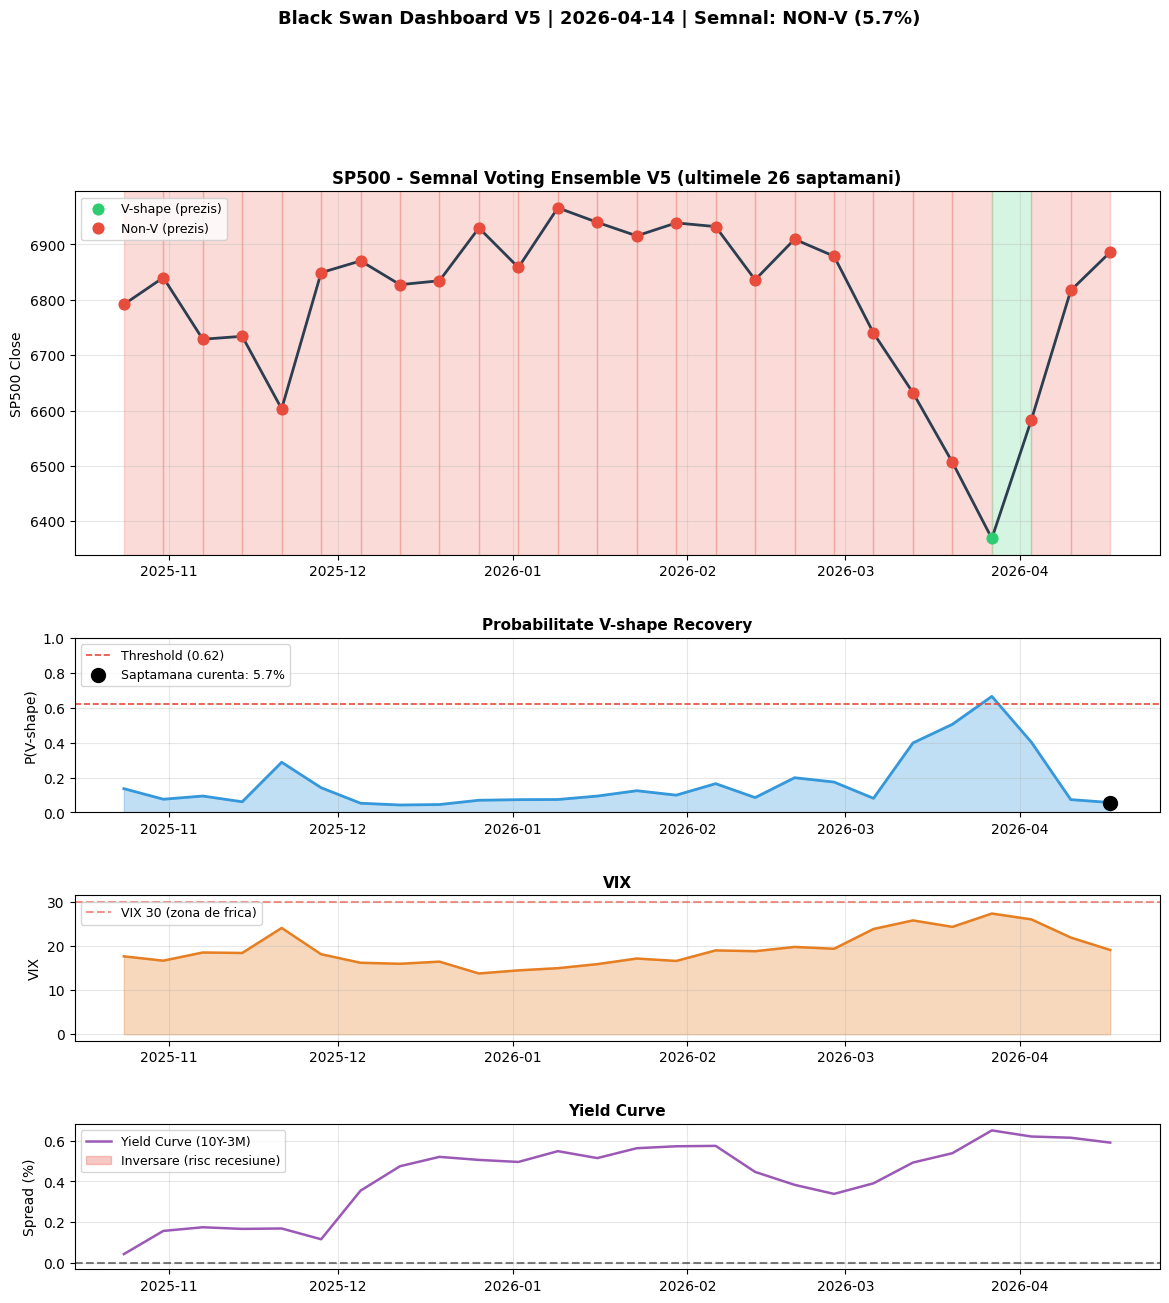

Salvat: plots/dashboard_v5_2026-04-14.png


In [52]:
# Construim X pentru ultimele 26 saptamani
weekly_26 = weekly.iloc[-26:].copy()

X_plot = pd.DataFrame(
    np.zeros((len(weekly_26), len(FEATURE_COLS))),
    columns=FEATURE_COLS,
    index=weekly_26.index
)

for col in FEATURE_COLS:
    if col in weekly_26.columns:
        X_plot[col] = weekly_26[col].fillna(0.0).values

X_plot_s = scaler.transform(X_plot.values)
probas   = ensemble.predict_proba(X_plot_s)[:, 1]
preds    = (probas >= OPTIMAL_THRESHOLD).astype(int)
prices   = weekly_26['SP500_Close']
vix_plot = weekly_26['VIX']
yc_plot  = weekly_26['Yield_Curve']

fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(4, 1, height_ratios=[2.5, 1.2, 1, 1], hspace=0.4)

# --- Plot 1: SP500 colorat dupa semnal ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(prices.index, prices.values, color='#2c3e50', linewidth=2, zorder=3)

for i in range(len(X_plot) - 1):
    color = '#2ecc71' if preds[i] == 1 else '#e74c3c'
    ax1.axvspan(X_plot.index[i], X_plot.index[i+1], alpha=0.2, color=color)

for lbl, color, label in [(1, '#2ecc71', 'V-shape (prezis)'), (0, '#e74c3c', 'Non-V (prezis)')]:
    mask = preds == lbl
    if mask.any():
        ax1.scatter(prices.index[mask], prices.values[mask],
                   color=color, s=60, zorder=5, label=label)

ax1.set_title('SP500 - Semnal Voting Ensemble V5 (ultimele 26 saptamani)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('SP500 Close')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Probabilitate ---
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(X_plot.index, probas, alpha=0.3, color='#3498db')
ax2.plot(X_plot.index, probas, color='#3498db', linewidth=2)
ax2.axhline(OPTIMAL_THRESHOLD, color='#e74c3c', linestyle='--', linewidth=1.2,
            label='Threshold (' + str(round(OPTIMAL_THRESHOLD, 2)) + ')')
ax2.scatter([X_plot.index[-1]], [probas[-1]], color='black', s=100, zorder=5,
            label='Saptamana curenta: ' + str(round(float(probas[-1])*100, 1)) + '%')
ax2.set_ylabel('P(V-shape)')
ax2.set_ylim(0, 1)
ax2.set_title('Probabilitate V-shape Recovery', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: VIX ---
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(vix_plot.index, vix_plot.values, alpha=0.3, color='#e67e22')
ax3.plot(vix_plot.index, vix_plot.values, color='#e67e22', linewidth=1.8)
ax3.axhline(30, color='#e74c3c', linestyle='--', alpha=0.6, label='VIX 30 (zona de frica)')
ax3.set_ylabel('VIX')
ax3.set_title('VIX', fontsize=11, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

# --- Plot 4: Yield Curve ---
ax4 = fig.add_subplot(gs[3])
ax4.plot(yc_plot.index, yc_plot.values, color='#9b59b6', linewidth=1.8,
         label='Yield Curve (10Y-3M)')
ax4.fill_between(yc_plot.index, yc_plot.values, 0,
                 where=yc_plot.values < 0, alpha=0.3, color='#e74c3c',
                 label='Inversare (risc recesiune)')
ax4.axhline(0, color='black', linestyle='--', alpha=0.5)
ax4.set_ylabel('Spread (%)')
ax4.set_title('Yield Curve', fontsize=11, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle(
    'Black Swan Dashboard V5 | ' + TODAY + ' | Semnal: ' + signal +
    ' (' + str(round(proba_v*100, 1)) + '%)',
    fontsize=13, fontweight='bold', y=1.01
)
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/dashboard_v5_' + TODAY + '.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/dashboard_v5_' + TODAY + '.png')

## 9. Istoric Semnale

In [50]:
log_file = 'dashboard_v5_log.csv'

new_row = pd.DataFrame([{
    'date'            : TODAY,
    'sp500'           : round(float(current_price), 2),
    'vix'             : round(float(current_vix), 2),
    'drawdown_pct'    : round(float(current_drawdown) * 100, 2),
    'yield_curve'     : round(float(current_yield), 3),
    'credit_spread'   : round(float(current_spread), 3),
    'fed_rate'        : round(float(current_fed), 3),
    'p_vshape'        : round(float(proba_v), 4),
    'signal'          : signal,
    'crisis_active'   : crisis_active,
    'weeks_in_crisis' : weeks_in_crisis,
    'phase'           : phase
}])

if os.path.exists(log_file):
    log = pd.read_csv(log_file)
    log = pd.concat([log, new_row], ignore_index=True)
else:
    log = new_row

log.to_csv(log_file, index=False)
print('Log actualizat:', log_file)
print('\nIstoricul semnalelor:')
print(log.tail(10).to_string(index=False))

Log actualizat: dashboard_v5_log.csv

Istoricul semnalelor:
      date   sp500   vix  drawdown_pct  yield_curve  credit_spread  fed_rate  p_vshape signal  crisis_active  weeks_in_crisis  phase
2026-04-14 6886.24 19.12           0.0         0.59           2.94      3.64    0.0571  NON-V          False                0      1
